# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = 'dataset/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'

## 2 — Load & Inspect Data

In [20]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])

# SPLIT FOR VALIDATION
split_point = int(len(train) * 0.8)
train = train.sort_values('Date')
train_set = train.iloc[:split_point]
val_set = train.iloc[split_point:]
train = train_set
test = val_set

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3066, 3)
Train date range: 2012-07-04 → 2020-11-24

Test shape: (767, 3)
Test date range: 2020-11-25 → 2022-12-31



,Date,Revenue,COGS
3061,2020-11-20,1761075.99,1653768.63
3062,2020-11-21,1277317.49,1191035.20
3063,2020-11-22,1402812.95,1422457.39
3064,2020-11-23,1254495.47,1331674.56
3065,2020-11-24,1234768.03,1251831.61


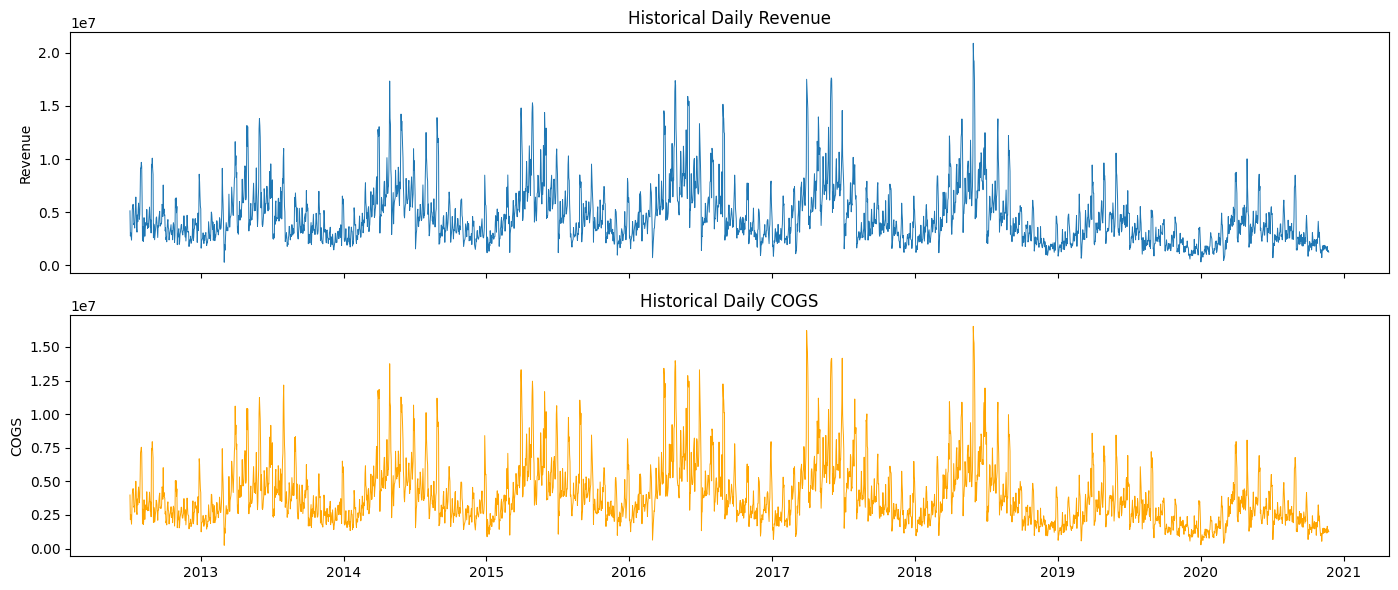

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [22]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.001580e+09  8.335090e+08


In [23]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2019]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9391  (-6.09%/yr)
Geometric mean YoY COGS    growth : 0.9390  (-6.10%/yr)


## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [24]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

Seasonal profile rows: 366


,month,day,rev_norm,cogs_norm
0,1,1,0.894015,0.958293
1,1,2,0.409564,0.407376
2,1,3,0.359165,0.335234
3,1,4,0.377024,0.346199
4,1,5,0.415293,0.378675
5,1,6,0.432911,0.401562
6,1,7,0.466726,0.436615
7,1,8,0.459933,0.427570
8,1,9,0.495298,0.465894
9,1,10,0.482489,0.439778


## 5 — Predict Test Period

In [25]:
# Base level: 2022 annual mean (most recent complete year)
last_full_year = 2019
# average of nearly year
base_rev  = annual.loc[last_full_year, 'Revenue']  / 365
base_cogs = annual.loc[last_full_year, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - last_full_year

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2020-11-25,1493734.75,1489464.28
1,2020-11-26,1824771.98,1818759.35
2,2020-11-27,2344020.63,2311791.98
3,2020-11-28,2407651.19,2408915.31
4,2020-11-29,2054648.26,2061736.12
5,2020-11-30,1972381.99,1951334.49
6,2020-12-01,1529499.03,1525202.97
7,2020-12-02,977436.91,977098.87
8,2020-12-03,1056456.75,1021182.01
9,2020-12-04,1138467.94,1103085.18


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

MAPE Revenue (2020): 21.62%
MAPE COGS    (2020): 22.33%


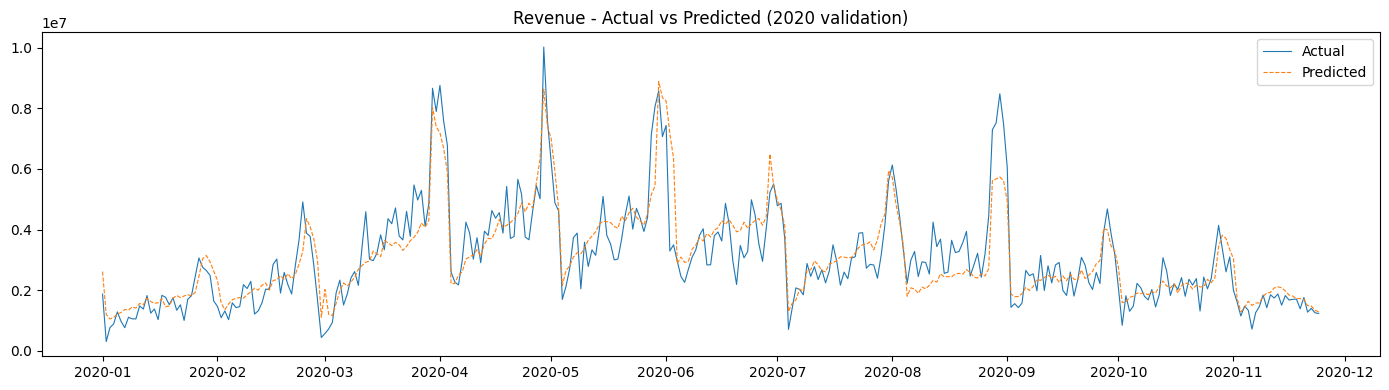

In [26]:
val = train[train['year'] == 2020].copy()

# Drop pre-existing normalized columns from train to avoid _x/_y suffixes after merge.
val = val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')
val = val.merge(seasonal, on=['month', 'day'], how='left')
val['rev_norm'] = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)

base_year = 2019
val['years_ahead'] = val['year'] - base_year
val['Revenue_pred'] = base_rev * growth_rev**val['years_ahead'] * val['rev_norm']
val['COGS_pred'] = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

def mape(actual, pred):
    actual = np.where(actual == 0, 1e-9, actual)
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2020): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2020): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue - Actual vs Predicted (2020 validation)')
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Export Submission

In [27]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 767 rows to dataset/submission.csv


,Date,Revenue,COGS
0,2020-11-25,1493734.75,1489464.28
1,2020-11-26,1824771.98,1818759.35
2,2020-11-27,2344020.63,2311791.98
3,2020-11-28,2407651.19,2408915.31
4,2020-11-29,2054648.26,2061736.12
5,2020-11-30,1972381.99,1951334.49
6,2020-12-01,1529499.03,1525202.97
7,2020-12-02,977436.91,977098.87
8,2020-12-03,1056456.75,1021182.01
9,2020-12-04,1138467.94,1103085.18
